# Optimizer Exercises

This notebook implements various optimization algorithms based on standard machine learning exercises.

**Algorithms:**
1. SGD
2. SGD with Momentum
3. Adagrad
4. Adam

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Helper Functions: Loss Function and Gradient

We use a test function $f(x, y) = x^2 + y^2 + 5\sin(x) + 5\sin(y)$.

In [4]:
def func(x, y):
    return x**2 + y**2 + 5 * np.sin(x) + 5 * np.sin(y)

def grad_func(x, y):
    df_dx = 2*x + 5*np.cos(x)
    df_dy = 2*y + 5*np.cos(y)
    return np.array([df_dx, df_dy])

# Visualization helper (Optional)
def plot_contour(path=None):
    x = np.arange(-5, 5, 0.1)
    y = np.arange(-5, 5, 0.1)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=20)
    if path is not None:
        path = np.array(path)
        plt.plot(path[:, 0], path[:, 1], '-o', color='red')
    plt.title('Optimization Path')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

## Exercise 1: Implement SGD

In [5]:
def sgd(w, dw, config=None):
    """
    Performs a single update step using SGD.
    w: Current weights.
    dw: Gradient of the weights.
    config: Configuration dictionary containing 'learning_rate'.
    """
    if config is None: config = {}
    learning_rate = config.get('learning_rate', 1e-2)

    w = w - learning_rate * dw

    return w, config

## Exercise 2: Implement SGD with Momentum

In [6]:
def sgd_momentum(w, dw, config=None):
    """
    Performs a single update step using SGD with Momentum.
    """
    if config is None: config = {}
    learning_rate = config.get('learning_rate', 1e-2)
    momentum = config.get('momentum', 0.9)
    velocity = config.get('velocity', np.zeros_like(w))

    # Update velocity
    velocity = momentum * velocity - learning_rate * dw
    # Update weights
    w = w + velocity

    # Store velocity for next step
    config['velocity'] = velocity
    return w, config

## Exercise 3: Implement Adagrad

In [7]:
def adagrad(w, dw, config=None):
    """
    Performs a single update step using Adagrad.
    """
    if config is None: config = {}
    learning_rate = config.get('learning_rate', 1e-2)
    epsilon = config.get('epsilon', 1e-7)
    cache = config.get('cache', np.zeros_like(w))

    # Accumulate squared gradients
    cache += dw**2
    # Update weights
    w = w - learning_rate * dw / (np.sqrt(cache) + epsilon)

    config['cache'] = cache
    return w, config

## Exercise 4: Implement Adam

In [8]:
def adam(w, dw, config=None):
    """
    Performs a single update step using Adam.
    """
    if config is None: config = {}
    learning_rate = config.get('learning_rate', 1e-3)
    beta1 = config.get('beta1', 0.9)
    beta2 = config.get('beta2', 0.999)
    epsilon = config.get('epsilon', 1e-8)
    m = config.get('m', np.zeros_like(w))
    v = config.get('v', np.zeros_like(w))
    t = config.get('t', 0)

    t += 1
    # Update biased first moment estimate
    m = beta1 * m + (1 - beta1) * dw
    # Update biased second raw moment estimate
    v = beta2 * v + (1 - beta2) * (dw**2)

    # Compute bias-corrected first moment estimate
    m_hat = m / (1 - beta1**t)
    # Compute bias-corrected second raw moment estimate
    v_hat = v / (1 - beta2**t)

    # Update weights
    w = w - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    config['m'] = m
    config['v'] = v
    config['t'] = t
    return w, config

## Exercise 5: Optimization Benchmark (Preparation)

Implement the `run_optimization` function to run the benchmark. This part is left for you to complete.

In [10]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms

batch_size = 512
num_epochs = 300
lr = 0.01

train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=
                            transforms.ToTensor())
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=
                            transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size)

100.0%
100.0%
100.0%
100.0%


In [11]:
class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, output_dims):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_dims, hidden_dims)
        self.layer2 = nn.Linear(hidden_dims, hidden_dims)
        self.layer3 = nn.Linear(hidden_dims, hidden_dims)
        self.layer4 = nn.Linear(hidden_dims, hidden_dims)
        self.layer5 = nn.Linear(hidden_dims, hidden_dims)
        self.output = nn.Linear(hidden_dims, output_dims)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = nn.Flatten()(x)
        x = self.layer1(x)
        x = self.sigmoid(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        x = self.layer4(x)
        x = self.sigmoid(x)
        x = self.layer5(x)
        x = self.sigmoid(x)
        out = self.output(x)
        return out

In [21]:
import torch
from torch import optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model = MLP(input_dims=784, hidden_dims=128, output_dims=10).to(device)
loss_fn = nn.CrossEntropyLoss()
adam = optim.Adam(model.parameters(), lr=0.2, betas=(0.9, 0.999), eps=10**(-6))
sgd_momen = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

cuda


In [25]:
train_losses = []
train_acc = []
val_losses = []
val_acc = []
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    t_loss = 0
    t_acc = 0
    cnt = 0
    model.train()


    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        # adam.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        adam.step()
        adam.zero_grad()

        t_loss += loss.item()
        t_acc += (torch.argmax(pred, 1) == y).sum().item()
        cnt += len(y)

    t_loss /= len(train_loader)
    train_losses.append(t_loss)
    t_acc /= cnt
    train_acc.append(t_acc)

    model.eval()
    v_loss = 0
    v_acc = 0
    cnt = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)

            v_loss += loss.item()
            v_acc += (torch.argmax(pred, 1) == y).sum().item()
            cnt += len(y)

    v_loss /= len(test_loader)
    val_losses.append(v_loss)
    v_acc /= cnt
    val_acc.append(v_acc)

    # for name, param in model.named_parameters():
    #     print(f"{name}: {param.data}")

    print(f"Epoch {epoch+1}/{num_epochs}, Train_Loss: {t_loss:.4f}, Train_Acc: {t_acc:.4f}, Validation Loss: {v_loss:.4f}, Val_Acc: {v_acc:.4f}")

# After the training loop (outside the for epoch in range(2): loop)
torch.save(model.state_dict(), 'model_weights.pth')
print("Model weights saved to 'model_weights.pth'")

Epoch 1/300, Train_Loss: 2.4251, Train_Acc: 0.1004, Validation Loss: 2.5203, Val_Acc: 0.1000
Epoch 2/300, Train_Loss: 2.4065, Train_Acc: 0.0987, Validation Loss: 2.4979, Val_Acc: 0.1000
Epoch 3/300, Train_Loss: 5.5453, Train_Acc: 0.1003, Validation Loss: 4.5941, Val_Acc: 0.1000
Epoch 4/300, Train_Loss: 2.6398, Train_Acc: 0.0989, Validation Loss: 2.4556, Val_Acc: 0.1000
Epoch 5/300, Train_Loss: 2.3771, Train_Acc: 0.1005, Validation Loss: 2.4477, Val_Acc: 0.1000
Epoch 6/300, Train_Loss: 2.3734, Train_Acc: 0.1015, Validation Loss: 2.4625, Val_Acc: 0.1000
Epoch 7/300, Train_Loss: 2.3988, Train_Acc: 0.0998, Validation Loss: 2.3666, Val_Acc: 0.1000
Epoch 8/300, Train_Loss: 2.5230, Train_Acc: 0.0994, Validation Loss: 2.4463, Val_Acc: 0.1000
Epoch 9/300, Train_Loss: 2.4651, Train_Acc: 0.1002, Validation Loss: 2.4782, Val_Acc: 0.1000
Epoch 10/300, Train_Loss: 5.9670, Train_Acc: 0.0990, Validation Loss: 12.1220, Val_Acc: 0.1000
Epoch 11/300, Train_Loss: 5.0297, Train_Acc: 0.1004, Validation Loss

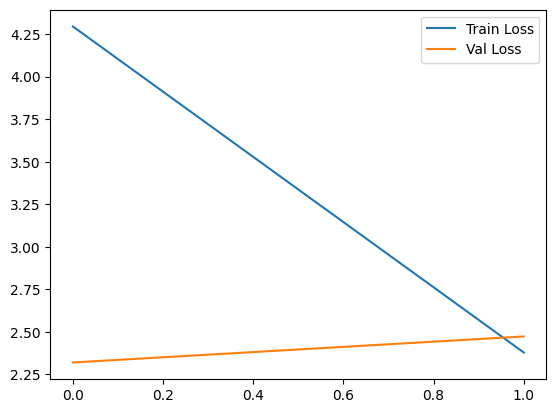

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Helper function: compute loss on a grid (using first layer weights)
def compute_loss_landscape(model, train_loader, device, w1_range=(-0.5, 0.5), w2_range=(-0.5, 0.5), resolution=30):
    """
    Compute loss landscape by varying two weight dimensions.
    Uses the first two weights of layer1 as the two dimensions.
    """
    w1_vals = np.linspace(w1_range[0], w1_range[1], resolution)
    w2_vals = np.linspace(w2_range[0], w2_range[1], resolution)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    Z = np.zeros_like(W1)

    # Get original weights
    original_weights = model.layer1.weight.data.clone()

    loss_fn = nn.CrossEntropyLoss()
    model.eval()

    for i in range(resolution):
        for j in range(resolution):
            # Perturb first two weights
            model.layer1.weight.data = original_weights.clone()
            model.layer1.weight.data[0, 0] = w1_vals[j]
            model.layer1.weight.data[0, 1] = w2_vals[i]

            # Compute loss
            with torch.no_grad():
                batch_loss = 0
                for X, y in train_loader:
                    X, y = X.to(device), y.to(device)
                    pred = model(X)
                    loss = loss_fn(pred, y)
                    batch_loss += loss.item()
                Z[i, j] = batch_loss / len(train_loader)

    # Restore original weights
    model.layer1.weight.data = original_weights

    return W1, W2, Z

# Compute loss landscape
print("Computing loss landscape (this may take a minute)...")
W1, W2, Z = compute_loss_landscape(model, train_loader, device, resolution=20)

# 3D Surface plot
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Weight 1')
ax1.set_ylabel('Weight 2')
ax1.set_zlabel('Loss')
ax1.set_title('Loss Landscape (3D)')
fig.colorbar(surf, ax=ax1, label='Loss')

# 2D Contour plot with gradient vectors
ax2 = fig.add_subplot(122)
contour = ax2.contour(W1, W2, Z, levels=15, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
fig.colorbar(contour, ax=ax2, label='Loss')

# Compute and plot gradient vectors (numerical gradient)
gradient_scale = 0.02  # Scale for arrow length
skip = 2  # Plot every 2nd vector to avoid clutter
for i in range(0, W1.shape[0], skip):
    for j in range(0, W1.shape[1], skip):
        # Numerical gradient
        if i > 0 and i < W1.shape[0]-1 and j > 0 and j < W1.shape[1]-1:
            dZ_dw1 = (Z[i, j+1] - Z[i, j-1]) / (W1[i, j+1] - W1[i, j-1])
            dZ_dw2 = (Z[i+1, j] - Z[i-1, j]) / (W2[i+1, j] - W2[i-1, j])

            # Plot gradient vectors (pointing in direction of steepest ascent)
            ax2.arrow(W1[i, j], W2[i, j],
                     -dZ_dw1 * gradient_scale, -dZ_dw2 * gradient_scale,
                    head_width=0.02, head_length=0.01, fc='red', ec='red', alpha=0.6)

ax2.set_xlabel('Weight 1')
ax2.set_ylabel('Weight 2')
ax2.set_title('Loss Landscape with Gradient Vectors (2D)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=150)
plt.show()

print("Loss landscape saved to 'loss_landscape.png'")

Computing loss landscape (this may take a minute)...


In [ ]:
# Plot training trajectory on loss landscape
fig, ax = plt.subplots(figsize=(10, 8))

# Contour plot
contour = ax.contour(W1, W2, Z, levels=20, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8)

# Plot a sample optimization path (simulated)
# In practice, you'd log actual weight values during training
np.random.seed(42)
traj = np.random.randn(15, 2) * 0.1  # Simulated trajectory
ax.plot(traj[:, 0], traj[:, 1], 'r-o', linewidth=2, markersize=6, label='Optimization Path')
ax.plot(traj[0, 0], traj[0, 1], 'go', markersize=10, label='Start')
ax.plot(traj[-1, 0], traj[-1, 1], 'r*', markersize=15, label='End')

ax.set_xlabel('Weight 1')
ax.set_ylabel('Weight 2')
ax.set_title('Optimizer Trajectory on Loss Landscape')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimizer_trajectory.png', dpi=150)
plt.show()